# ParaSpeechCaps

In [ ]:
import json
import pandas as pd


with open("C:/Users/jackm/Documents/GitHub/ms-capstone-TTS-natlang-styleprompts/src/data/raw/paraspeechcaps/audio/EARS/speaker_statistics.json", "r") as f:
    data = json.load(f)

# keys -> index, then move index into a column
df = pd.DataFrame.from_dict(data, orient="index").reset_index()

# rename the index column
psc_df = df.rename(columns={"index": "speaker_id"})

df

Show distributions of stats in EARS:

In [ ]:
import matplotlib.pyplot as plt

stat_columns = [c for c in df.columns if c != "speaker_id"]

for col in stat_columns:
    plt.figure()
    ax = psc_df[col].value_counts().sort_index().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

    # add numbers on top of bars
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


To get a more balanced speaker set, we want to reduce some speakers of the majority classes (white/caucasian, american english).
This information will help us choose which files to not download from EARS.
Hopefully this allows the model to generalize more.

In [18]:
criteria = {
    "ethnicity": "white or caucasian",
    "native language" : "american english"
}

n = 20  # number of rows to pick

# Step 1: create mask for rows matching all criteria
mask = (df[list(criteria)] == pd.Series(criteria)).all(axis=1)

# Step 2: get the matching rows
matching = df[mask]

# Step 3: sample n rows from matches (safe if fewer than n exist)
selected = matching.sample(n=min(n, len(matching)), random_state=42)

# Step 4: remove selected rows from original dataframe
df_balanced = df.drop(selected.index)

df_balanced

,speaker_id,age,ethnicity,gender,weight,native language,height
0,p001,36-45,white or caucasian,male,160 - 180 lbs,german,6' - 6'3
2,p003,26-35,black or african american,female,100 - 120 lbs,american english,5'4 - 5'7
3,p004,18-25,white or caucasian,male,140 - 160 lbs,american english,5'8 - 5'11
4,p005,18-25,asian,male,140 - 160 lbs,mandarin,5'4 - 5'7
5,p006,36-45,hispanic or latino,female,200 - 220 lbs,american english,< 5'
...,...,...,...,...,...,...,...
102,p103,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer,prefer not to answer
103,p104,56-65,white or caucasian,female,180 - 200 lbs,american english,5'4 - 5'7
104,p105,36-45,black or african american,male,220 - 240 lbs,american english,6' - 6'3
105,p106,56-65,white or caucasian,female,120 - 140 lbs,american english,5' - 5'3


new distributions:

In [ ]:
import matplotlib.pyplot as plt

stat_columns = [c for c in df_balanced.columns if c != "speaker_id"]

for col in stat_columns:
    plt.figure()
    ax = df_balanced[col].value_counts().sort_index().plot(kind="bar")

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")

    # add numbers on top of bars
    for p in ax.patches:
        ax.annotate(
            str(int(p.get_height())),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# get speaker ids to EXCLUDE
list(selected["speaker_id"])

## PSC Annotations

In [3]:
from datasets import load_dataset
import pandas as pd


train_base = load_dataset("ajd12342/paraspeechcaps", split="train_base") 
holdout = load_dataset("ajd12342/paraspeechcaps", split="holdout")
dev = load_dataset("ajd12342/paraspeechcaps", split="dev")
test = load_dataset("ajd12342/paraspeechcaps", split="test")

psc_dfs = [
    train_base.to_pandas(),
    holdout.to_pandas(),
    dev.to_pandas(),
    test.to_pandas(),
]

# merge into one dataframe
psc_df = pd.concat(psc_dfs, ignore_index=True)

# filter out VoxCeleb, Emilia
psc_df = psc_df[psc_df["source"] != "voxceleb"]
psc_df = psc_df[psc_df["source"] != "emilia"]

c:\Users\jackm\miniconda3\envs\capstone-eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# only Emilia, AI generated styles
train_scaled = load_dataset("ajd12342/paraspeechcaps", split="train_scaled")
train_scaled.to_pandas()

In [ ]:
# Just Ears
ears_df = df[df["source"] == "ears"]

ears_df

In [ ]:
# Just Expresso
expresso_df = df[df["source"] == "expresso"]

expresso_df

In [ ]:
# Plot tag distribution

intrinsic_counts = (
    psc_df['intrinsic_tags']
    .explode()
    .value_counts()
    .reset_index()
)
situation_counts = (
    psc_df['situational_tags']
    .explode()
    .value_counts()
    .reset_index()
)

intrinsic_counts.columns = ['tag', 'count']
situation_counts.columns = ['tag', 'count']

tag_df = pd.concat([intrinsic_counts,situation_counts], ignore_index=True)

# print(situation_counts.head())
# print(intrinsic_counts.head())

In [ ]:
# treemaps
import matplotlib.pyplot as plt
import squarify
import os

os.makedirs('figures', exist_ok=True)

plt.figure(figsize=(16, 12))

squarify.plot(
    sizes=intrinsic_counts['count'],
    label=intrinsic_counts['tag'],
    alpha=0.8
)

plt.axis('off')
plt.title('Distribution of intrinsic tags')
plt.show()
plt.savefig(f"figures/psc_intrinsic_tag_treemap.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12,9))

squarify.plot(
    sizes=situation_counts['count'],
    label=situation_counts['tag'],
    alpha=0.8
)

plt.axis('off')
plt.title('Distribution of situational tags')
plt.show()
plt.savefig(f"figures/psc_situational_tag_treemap.png", dpi=300, bbox_inches="tight")
plt.close()

Processing rows: 100%|██████████| 22784/22784 [00:00<00:00, 173169.42it/s]


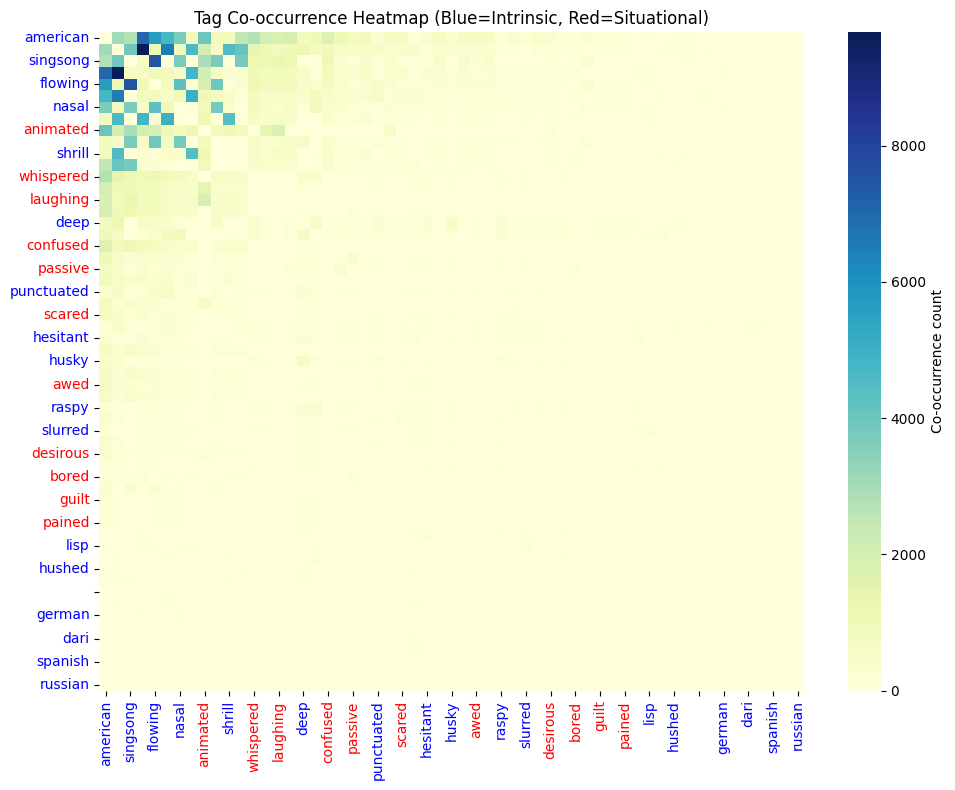

In [29]:
# Co-occurence heatmap
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm

psc_df = psc_df[psc_df['situational_tags'].notna()]
psc_df = psc_df[psc_df['intrinsic_tags'].notna()]
# Step 1: Get all unique tags and their types
intrinsic_tags = set(tag for tags in psc_df['intrinsic_tags'] for tag in tags)
situational_tags = set(tag for tags in psc_df['situational_tags'] for tag in tags)

all_tags = list(intrinsic_tags | situational_tags)
tag_types = {tag: 'intrinsic' if tag in intrinsic_tags else 'situational' for tag in all_tags}

# Step 2: Build co-occurrence matrix
co_matrix = pd.DataFrame(0, index=all_tags, columns=all_tags)
all_pairs = []
for intrinsic, situational in tqdm(zip(psc_df['intrinsic_tags'], psc_df['situational_tags']),
                                    total=len(psc_df), desc="Processing rows"):
    combined_tags = list(intrinsic) + list(situational)  # safe conversion
    if len(combined_tags) < 2:
        continue  # skip rows with <2 tags
    all_pairs.extend(combinations(combined_tags, 2))

# Step 4: Count occurrences of each pair
from collections import Counter

pair_counts = Counter(all_pairs)

# Step 5: Fill the co-occurrence matrix
for (t1, t2), count in pair_counts.items():
    co_matrix.loc[t1, t2] = count
    co_matrix.loc[t2, t1] = count  # symmetric
    
# Remove rows where all values are 0
co_matrix = co_matrix.loc[~(co_matrix==0).all(axis=1), :]

# Remove columns where all values are 0
co_matrix = co_matrix.loc[:, ~(co_matrix==0).all(axis=0)]

# Compute total co-occurrence per tag
tag_totals = co_matrix.sum(axis=1)

# Sort tags by descending total count
sorted_tags = tag_totals.sort_values(ascending=False).index

# Reorder matrix
co_matrix_sorted = co_matrix.loc[sorted_tags, sorted_tags]
# Step 3: Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_sorted, annot=False, fmt="d", cmap='YlGnBu', cbar_kws={'label': 'Co-occurrence count'})


# Step 4: Color the tick labels
ax = plt.gca()

# X-axis
for label in ax.get_xticklabels():
    tag = label.get_text()
    if tag_types[tag] == 'intrinsic':
        label.set_color('blue')
    else:
        label.set_color('red')

# Y-axis
for label in ax.get_yticklabels():
    tag = label.get_text()
    if tag_types[tag] == 'intrinsic':
        label.set_color('blue')
    else:
        label.set_color('red')

plt.title("Tag Co-occurrence Heatmap (Blue=Intrinsic, Red=Situational)")
plt.tight_layout()
plt.show()


In [ ]:
# tSNE plot for situational tag occurence 
from sklearn.manifold import TSNE

psc_df_nona = psc_df[psc_df['situational_tags'].notna()]
tags = psc_df_nona['situational_tags'].explode().unique()

# Build tag-situation matrix
all_tags = list(tags)
matrix = np.zeros((len(psc_df_nona), len(all_tags)))

for i, tag_list in enumerate(psc_df_nona['situational_tags']):

    for t in tag_list:
        matrix[i, all_tags.index(t)] = 1

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
coords = tsne.fit_transform(matrix)  # transpose to get tag vectors

plt.figure(figsize=(10,8))
for i, t in enumerate(all_tags):
    x, y = coords[i]
    plt.scatter(x, y)
    plt.text(x+0.05, y+0.05, t)
plt.title("t-SNE projection of tag co-occurrence")
plt.show()

# StyleTalk

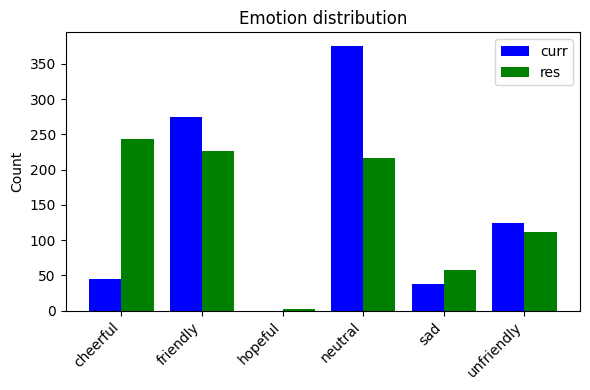

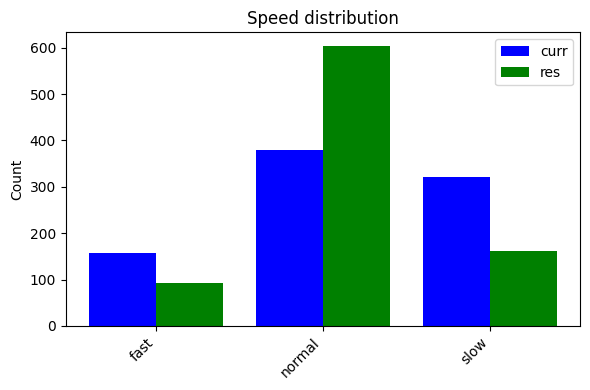

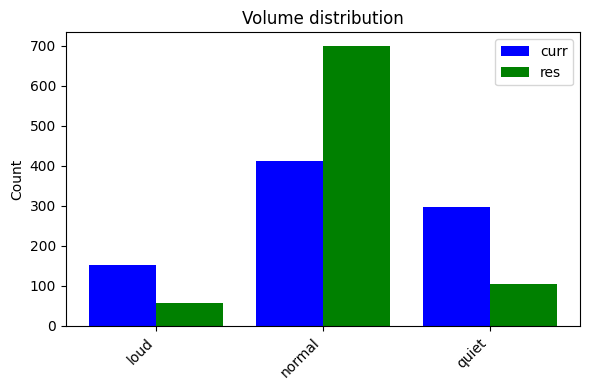

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os



def plot_curr_res_distribution(df, tag_base, figsize=(6, 4), width=0.4):
    # value counts
    curr = df[f'curr_{tag_base}'].value_counts()
    res = df[f'res_{tag_base}'].value_counts()

    # union of labels so both share the same x-axis
    labels = sorted(set(curr.index) | set(res.index))

    # reindex (missing → 0)
    curr = curr.reindex(labels, fill_value=0)
    res = res.reindex(labels, fill_value=0)

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(x - width/2, curr.values, width, label='curr', color='blue')
    ax.bar(x + width/2, res.values, width, label='res', color='green')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(f'{tag_base.capitalize()} distribution')
    ax.legend()

    fig.tight_layout()
    return fig, ax


os.makedirs("figures", exist_ok=True)

df = pd.read_csv(
    f"../data/raw/styletalk/annotations/eval.csv",
    sep=",",            # delimiter
    encoding="utf-8",   # or "latin1"
    na_values=["NA", ""],
)

for tag in ["emotion", "speed", "volume"]:
    fig, ax = plot_curr_res_distribution(df, tag)
    fig.savefig(f"figures/styletalk_{tag}_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

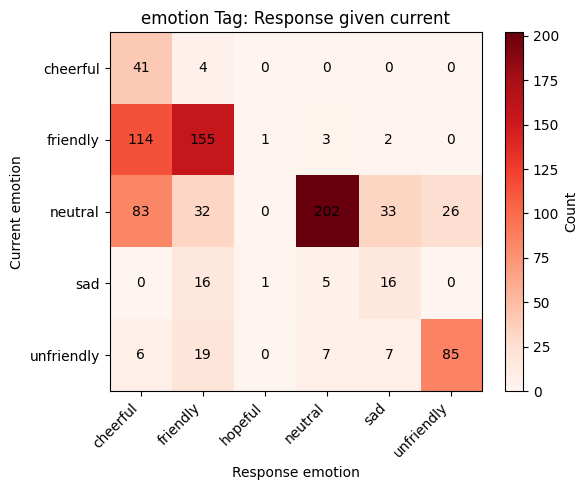

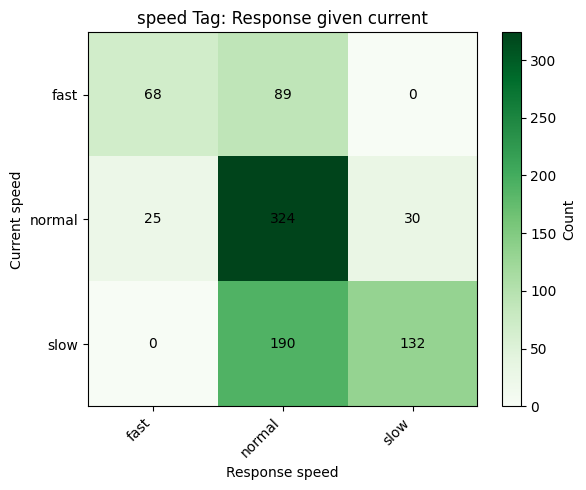

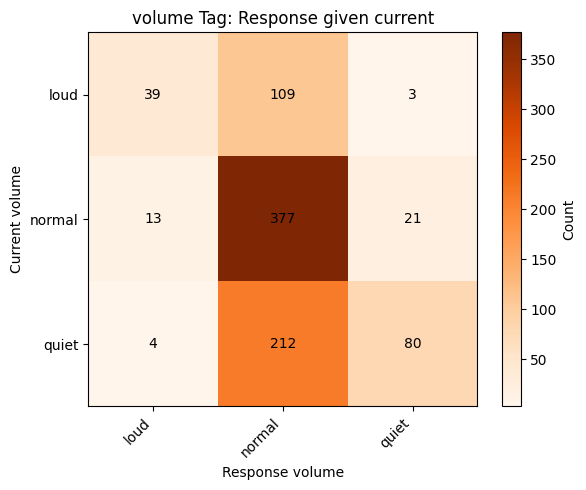

In [49]:
# Heatmap of conditional tags. p(res_emotion | curr_emotion), ...

import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
def create_cond_tag_plot(df, tag_base, colormap):
    ct = pd.crosstab(df[f"curr_{tag_base}"], df[f"res_{tag_base}"])

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(ct, aspect='auto', cmap=colormap)
    fig.colorbar(im, ax=ax, label='Count')

    ax.set_xticks(range(len(ct.columns)))
    ax.set_xticklabels(ct.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(ct.index)

    ax.set_xlabel('Response ' + tag_base)
    ax.set_ylabel('Current ' + tag_base)
    ax.set_title(tag_base + ' Tag: Response given current')

    # add numbers
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            value = ct.iloc[i, j]
            ax.text(j, i, value, ha='center', va='center', color='black')

    fig.tight_layout()
    return fig, ax
    

for tag, colormap in zip(['emotion','speed','volume'], ['Reds','Greens','Oranges']):
    fig, ax = create_cond_tag_plot(df, tag, colormap)
    plt.show()
    
    fig.savefig(f"figures/styletalk_{tag}_response_given_current.png", dpi=300, bbox_inches="tight")
    plt.close(fig)